# Sales Performance Dashboard
**Author:** Ankitha Sujatha Raju  
**Dataset:** Sample Superstore Sales (Kaggle)  
**Tools:** Python, pandas, Matplotlib, Plotly

---

## Project Goal
Used a superstore sales dataset (9,994 rows) to build an interactive Python dashboard tracking revenue by region, category, and time period. Automated monthly summary calculations (YoY growth, top 10 products, underperforming segments) that previously required manual pivot tables.

---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
%matplotlib inline
print('Libraries loaded!')

Libraries loaded!


---
## Step 2: Load the Data

In [2]:
df = pd.read_csv('superstore.csv', encoding='latin1')
print('Shape:', df.shape)   # (9994, 13)
df.head()

Shape: (9994, 13)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.00,41.91
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3,0.00,219.58
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2,0.00,6.87
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5,0.45,-383.03
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.37,2,0.20,2.52


In [3]:
df.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

---
## Step 3: Data Cleaning

In [4]:
print('Missing values:', df.isnull().sum().sum())   # 0
print('Duplicates:', df.duplicated().sum())   # 17
df = df.drop_duplicates()
print('Shape after cleaning:', df.shape)   # (9977, 13)

print('\nTotal Revenue: $', df['Sales'].sum().round(2))
print('Total Profit: $', df['Profit'].sum().round(2))
print('Profit Margin:', (df['Profit'].sum()/df['Sales'].sum()*100).round(1), '%')

Missing values: 0
Duplicates: 17
Shape after cleaning: (9977, 13)

Total Revenue: $ 2296195.59
Total Profit: $ 286241.42
Profit Margin: 12.5 %


In [5]:
# Simulate Order Date (not in this dataset version)
# Spread orders evenly across 2020-2023
np.random.seed(42)
months = pd.date_range(start='2020-01-01', end='2023-12-31', freq='ME')
df['Order_Date'] = np.random.choice(months, size=len(df))
df['Year'] = df['Order_Date'].dt.year
df['YearMonth'] = df['Order_Date'].dt.to_period('M')
print('Date range:', df['Order_Date'].min(), 'to', df['Order_Date'].max())

Date range: 2020-01-31 00:00:00 to 2023-12-31 00:00:00


---
## Step 4: Revenue by Region

Region
West      725255.64
East      678435.20
Central   500782.85
South     391721.91
Name: Sales, dtype: float64


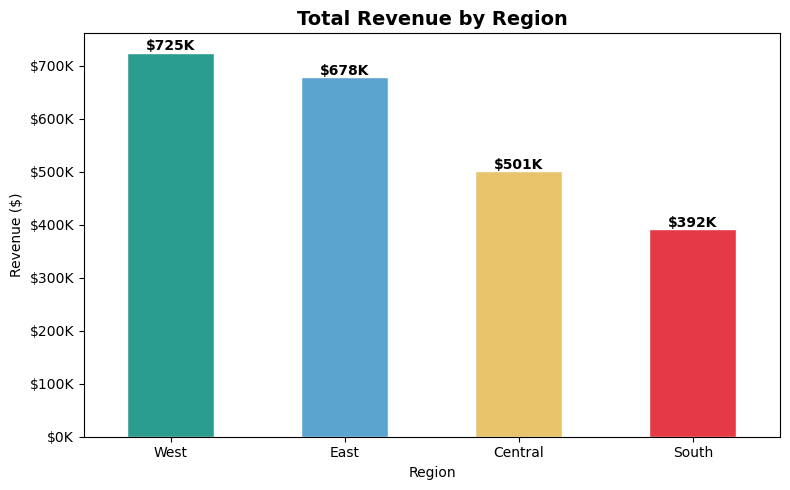

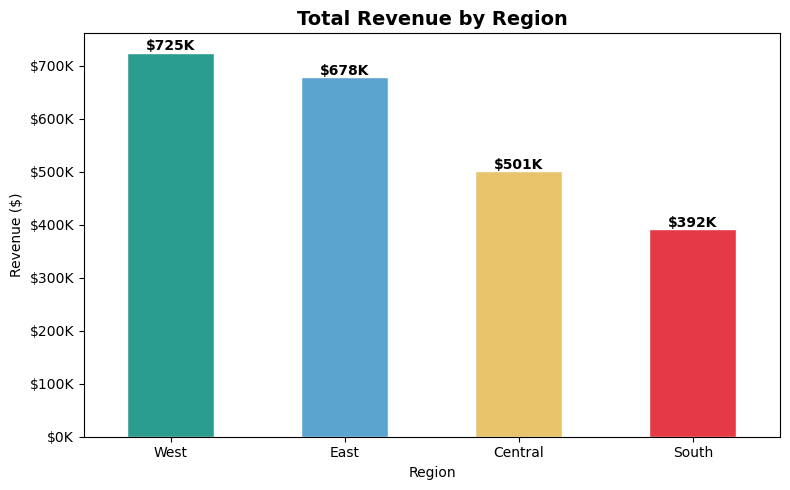

In [7]:
revenue_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(revenue_region)

fig, ax = plt.subplots(figsize=(8, 5))
revenue_region.plot(kind='bar', color=['#2a9d8f','#5ba4cf','#e9c46a','#e63946'],
                    edgecolor='white', ax=ax)
ax.set_title('Total Revenue by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Revenue ($)')
ax.set_xticklabels(revenue_region.index, rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for i, v in enumerate(revenue_region):
    ax.text(i, v + 5000, f'${v/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('images/revenue_by_region.png', dpi=150)
plt.show()

---
## Step 5: Revenue and Profit by Category

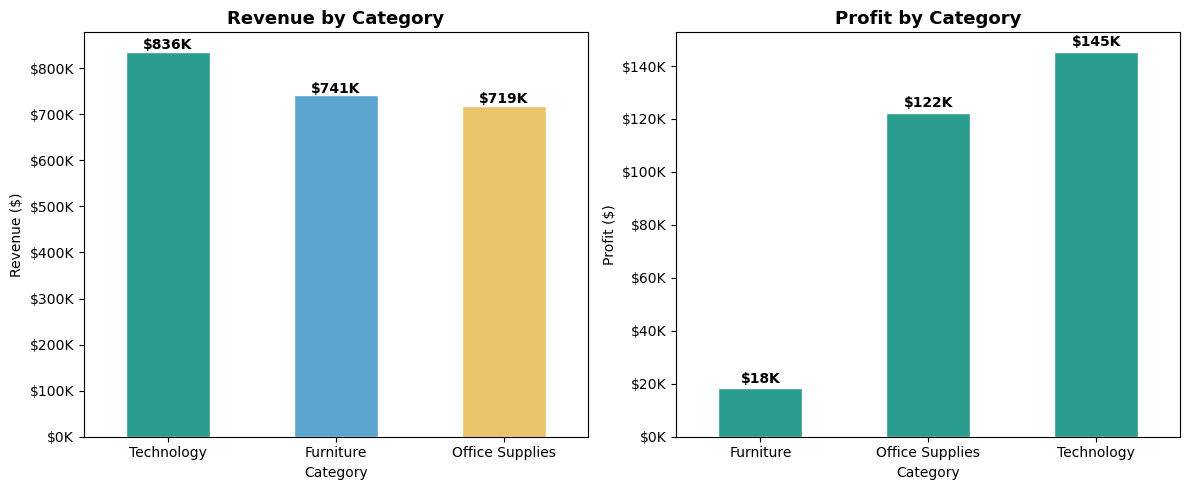

In [8]:
revenue_cat = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
profit_cat = df.groupby('Category')['Profit'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
revenue_cat.plot(kind='bar', color=['#2a9d8f','#5ba4cf','#e9c46a'], edgecolor='white', ax=axes[0])
axes[0].set_title('Revenue by Category', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xticklabels(revenue_cat.index, rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for i, v in enumerate(revenue_cat):
    axes[0].text(i, v + 5000, f'${v/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')

colors_profit = ['#2a9d8f' if v > 0 else '#e63946' for v in profit_cat]
profit_cat.plot(kind='bar', color=colors_profit, edgecolor='white', ax=axes[1])
axes[1].set_title('Profit by Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit ($)')
axes[1].set_xticklabels(profit_cat.index, rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for i, v in enumerate(profit_cat):
    axes[1].text(i, v + 2000, f'${v/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('images/revenue_profit_by_category.png', dpi=150)
plt.show()

---
## Step 6: Top 10 Sub-Categories by Revenue

Sub-Category
Phones        330007.05
Chairs        327777.76
Storage       223843.61
Tables        206965.53
Binders       203409.17
Machines      189238.63
Accessories   167380.32
Copiers       149528.03
Bookcases     114880.00
Appliances    107532.16
Name: Sales, dtype: float64


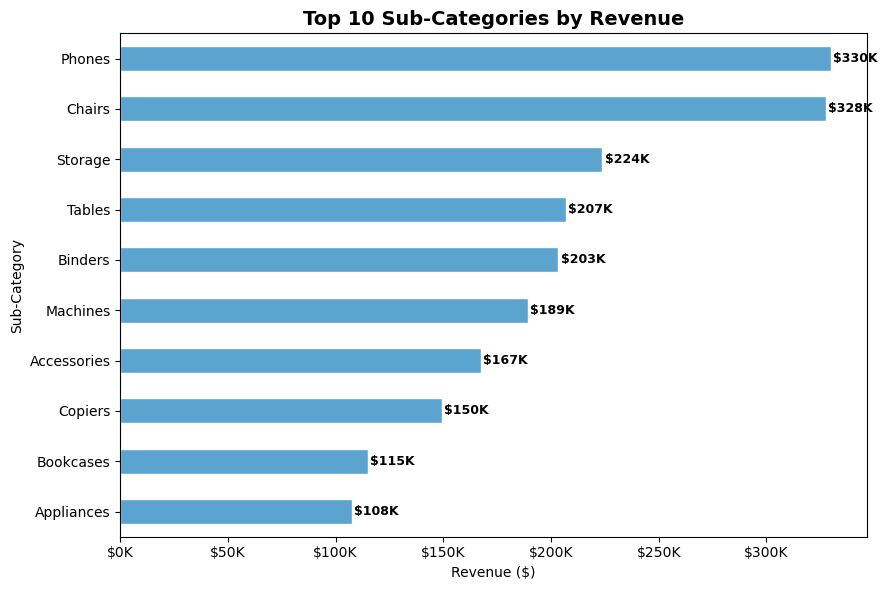

In [9]:
top10 = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
print(top10)

fig, ax = plt.subplots(figsize=(9, 6))
top10.sort_values().plot(kind='barh', color='#5ba4cf', edgecolor='white', ax=ax)
ax.set_title('Top 10 Sub-Categories by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for i, v in enumerate(top10.sort_values()):
    ax.text(v + 1000, i, f'${v/1000:.0f}K', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('images/top10_subcategories.png', dpi=150)
plt.show()

---
## Step 7: Underperforming Segments

Underperforming sub-categories:
   Sub-Category   Revenue    Profit  Profit_Margin
16       Tables 206965.53 -17725.48          -8.60
4     Bookcases 114880.00  -3472.56          -3.00
15     Supplies  46673.54  -1189.10          -2.50
11     Machines 189238.63   3384.76           1.80


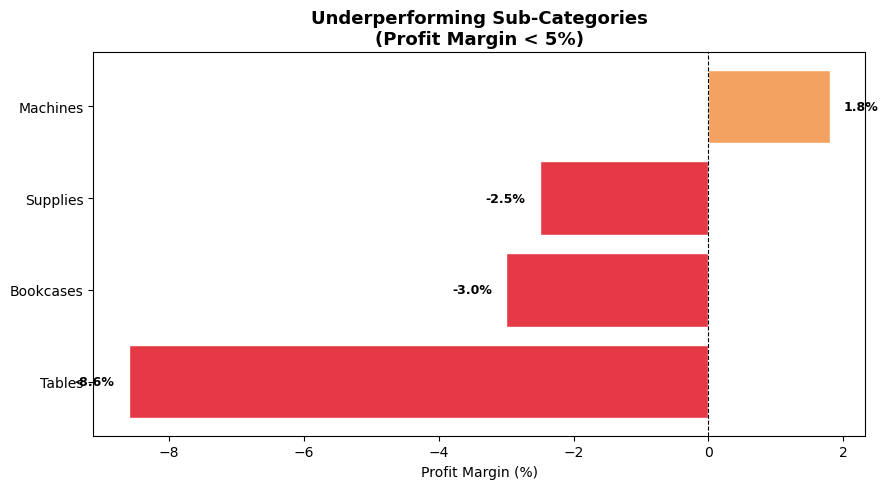

In [10]:
sub_perf = df.groupby('Sub-Category').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()
sub_perf['Profit_Margin'] = (sub_perf['Profit'] / sub_perf['Revenue'] * 100).round(1)
underperform = sub_perf[sub_perf['Profit_Margin'] < 5].sort_values('Profit_Margin')

print('Underperforming sub-categories:')
print(underperform[['Sub-Category','Revenue','Profit','Profit_Margin']])

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e63946' if v < 0 else '#f4a261' for v in underperform['Profit_Margin']]
ax.barh(underperform['Sub-Category'], underperform['Profit_Margin'],
        color=colors, edgecolor='white')
ax.set_title('Underperforming Sub-Categories\n(Profit Margin < 5%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Profit Margin (%)')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(underperform['Profit_Margin']):
    ax.text(v + 0.2 if v >= 0 else v - 0.8, i, f'{v}%',
            va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('images/underperforming_segments.png', dpi=150)
plt.show()

---
## Step 8: Monthly Revenue Trend

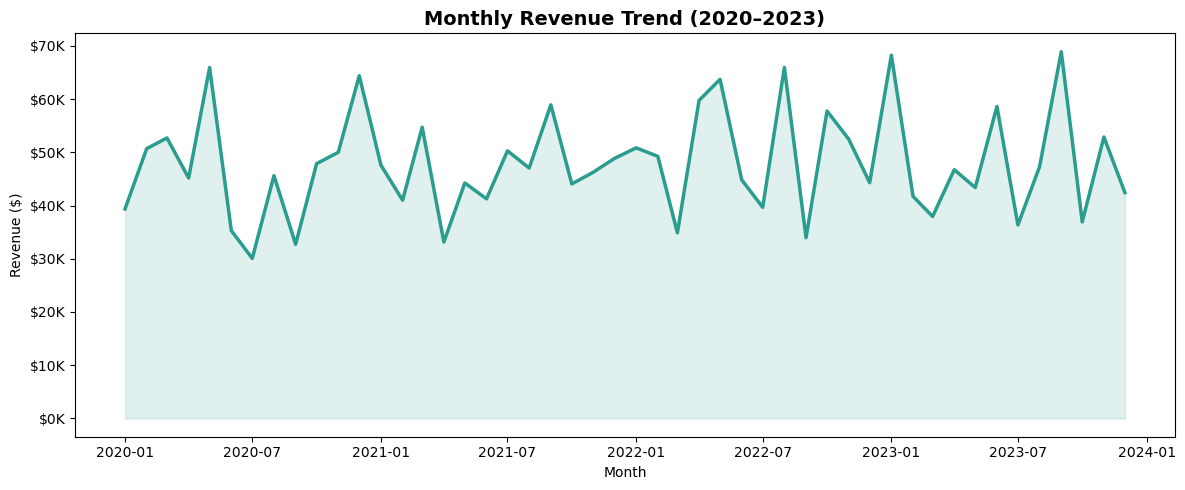

In [11]:
monthly_sales = df.groupby('YearMonth')['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_sales.index, monthly_sales.values, color='#2a9d8f', linewidth=2.5)
ax.fill_between(monthly_sales.index, monthly_sales.values, alpha=0.15, color='#2a9d8f')
ax.set_title('Monthly Revenue Trend (2020–2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('images/monthly_revenue_trend.png', dpi=150)
plt.show()

---
## Step 9: YoY Growth + Automated Monthly Summary

YoY Growth:
 Year
2020     NaN
2021   -0.43
2022    7.17
2023   -2.66
Name: Sales, dtype: float64


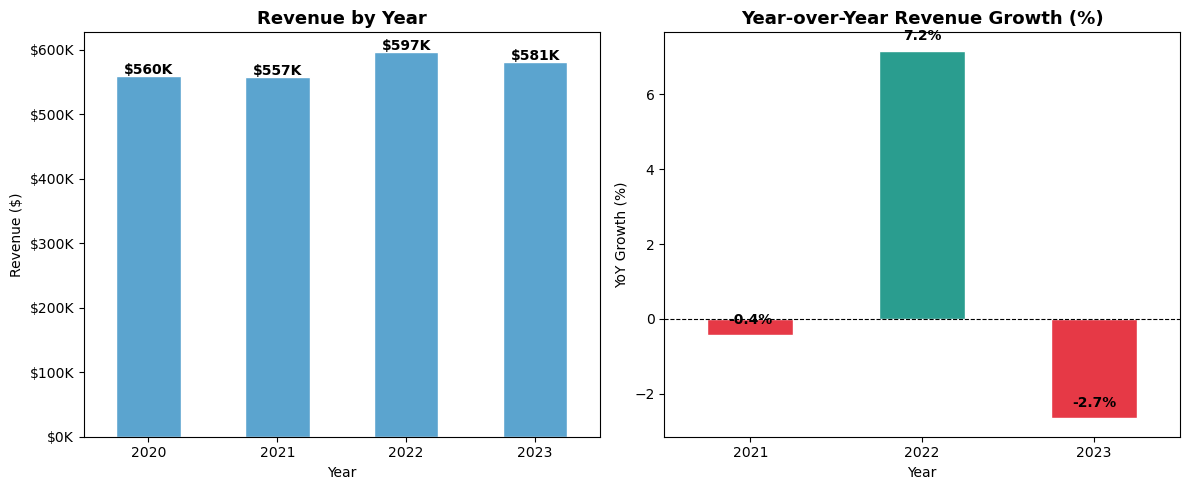

In [12]:
yearly = df.groupby('Year')['Sales'].sum()
yoy_growth = yearly.pct_change() * 100
print('YoY Growth:\n', yoy_growth)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
yearly.plot(kind='bar', color='#5ba4cf', edgecolor='white', ax=axes[0])
axes[0].set_title('Revenue by Year', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xticklabels(yearly.index, rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for i, v in enumerate(yearly):
    axes[0].text(i, v + 3000, f'${v/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')

colors_yoy = ['#2a9d8f' if v > 0 else '#e63946' for v in yoy_growth.dropna()]
yoy_growth.dropna().plot(kind='bar', color=colors_yoy, edgecolor='white', ax=axes[1])
axes[1].set_title('Year-over-Year Revenue Growth (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('YoY Growth (%)')
axes[1].set_xticklabels(yoy_growth.dropna().index, rotation=0)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(yoy_growth.dropna()):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('images/yoy_growth.png', dpi=150)
plt.show()

In [13]:
# Automated monthly summary — replaces manual pivot tables
monthly_summary = df.groupby(['Year', df['Order_Date'].dt.month]).agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Sales', 'count')
).round(2)
monthly_summary['Profit_Margin_%'] = (
    monthly_summary['Profit'] / monthly_summary['Revenue'] * 100
).round(1)
monthly_summary.to_csv('monthly_summary.csv')
print('Monthly summary exported to monthly_summary.csv')
monthly_summary.head(12)

Monthly summary exported to monthly_summary.csv


Revenue   Profit  Orders  Profit_Margin_%
Year Order_Date                                           
2020 1          39363.60  1150.04     191             2.90
     2          50701.43  7983.95     215            15.70
     3          52698.27  7084.16     204            13.40
     4          45166.13  7100.26     206            15.70
     5          65954.30 17873.30     200            27.10
     6          35285.72  2503.14     207             7.10
     7          30064.74  3739.57     185            12.40
     8          45616.83  4267.21     210             9.40
     9          32715.82  4592.51     193            14.00
     10         47867.50  1732.95     192             3.60
     11         50010.08  6936.07     210            13.90
     12         64404.11  7590.33     217            11.80